# Sobol + BO vs LHS+SA + BO — an end-to-end test

The DoE study picked **LHS+SA** over Sobol using *space-filling metrics* (discrepancy,
correlation, min distance). Those are proxies — this notebook checks the thing we actually care
about: **does the initializer change the outcome of the downstream Bayesian-optimization loop?**

**Test problem** (mimicking the campaign's structure at toy scale): one continuous input
`x ∈ [0, 1]` plus **one categorical input with 2 levels** (the Ox Press analogue). Level 0 is the
Forrester function `(6x−2)² sin(12x−4)`; level 1 is its correlated shifted variant — same family,
different optimum, so the GP must use both inputs.

**Protocol.** Two arms, identical in everything except the initial design:

* **Sobol + BO** — scrambled Sobol initial design (`n_init` points, snapped to the resolution grid).
* **LHS+SA + BO** — `conditional_sa_lhs` initial design (same snapping).

Both arms then run the *same* BO loop: the campaign's own GP (`utils.mobo.fit_gp` —
`SingleTaskGP`, standardized outcome) + analytic **LogEI**, one evaluation per iteration on a
shared candidate grid, noisy observations. Repeated over many seeds; we track **simple regret**
(best observed true value − achievable optimum).

Shared code lives in [`utils/doe_bo_test.py`](../../utils/doe_bo_test.py), so each arm can also be
run in its own notebook if needed.

In [1]:
import os, sys, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

REPO_ROOT = '/data/zhq7531/IDEAL/DMREF/repository_dmref'
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from utils.doe_bo_test import (CAND, TRUE_MIN, forrester, forrester_shift,
                               make_initial, run_benchmark, regret_matrix)

OUT_DIR = 'output/sampler_bo_1d_test'
os.makedirs(OUT_DIR, exist_ok=True)
sns.set_theme(style='whitegrid')

ARMS = {'sobol': ('Sobol + BO', '#1f77b4'), 'lhs_sa': ('LHS+SA + BO', '#d62728')}
N_SEEDS, N_INIT, N_ITER, SIGMA = 30, 8, 15, 1.0
print(f'{N_SEEDS} seeds x ({N_INIT} init + {N_ITER} BO evals), noise sigma = {SIGMA}')
print('Outputs ->', OUT_DIR)

30 seeds x (8 init + 15 BO evals), noise sigma = 1.0
Outputs -> output/sampler_bo_1d_test


## 1. The test problem

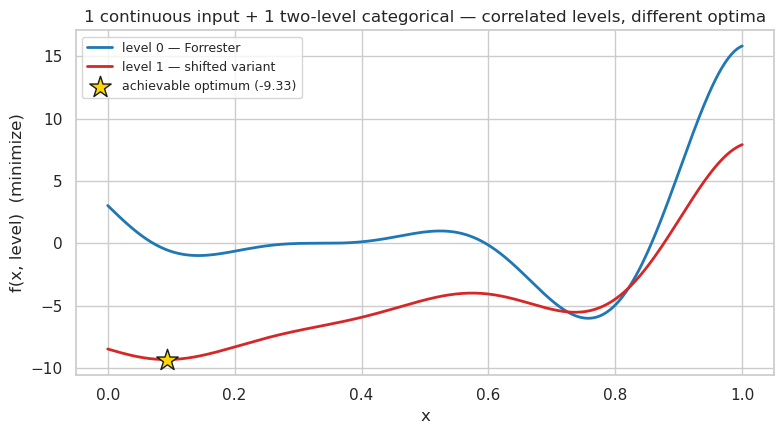

In [2]:
xg = np.linspace(0, 1, 400)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(xg, forrester(xg), color='#1f77b4', lw=2, label='level 0 — Forrester')
ax.plot(xg, forrester_shift(xg), color='#d62728', lw=2, label='level 1 — shifted variant')
i_best = int(np.argmin([forrester(xg).min(), forrester_shift(xg).min()]))
best_curve = [forrester, forrester_shift][i_best]
xb = xg[np.argmin(best_curve(xg))]
ax.scatter([xb], [best_curve(xb)], marker='*', s=260, color='gold', edgecolor='k', zorder=5,
           label=f'achievable optimum ({TRUE_MIN:.2f})')
ax.set_xlabel('x'); ax.set_ylabel('f(x, level)  (minimize)')
ax.set_title('1 continuous input + 1 two-level categorical — correlated levels, different optima')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'test_problem.png'), dpi=180, bbox_inches='tight')
plt.show()

## 2. What the two initial designs look like (one example seed)

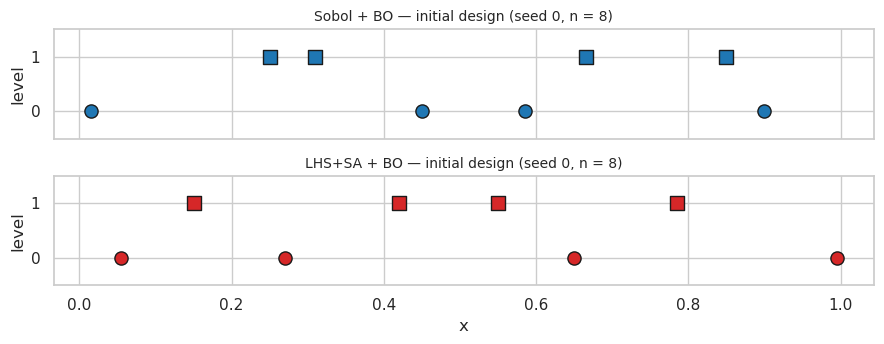

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(9, 3.6), sharex=True)
for ax, (key, (label, color)) in zip(axes, ARMS.items()):
    D = make_initial(key, N_INIT, seed=0)
    for lv, mk in [(0.0, 'o'), (1.0, 's')]:
        m = D[:, 1] == lv
        ax.scatter(D[m, 0], np.full(m.sum(), lv), marker=mk, s=90, color=color, edgecolor='k')
    ax.set_yticks([0, 1]); ax.set_ylabel('level'); ax.set_ylim(-0.5, 1.5)
    ax.set_title(f'{label} — initial design (seed 0, n = {N_INIT})', fontsize=10)
axes[-1].set_xlabel('x')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'initial_designs_example.png'), dpi=180, bbox_inches='tight')
plt.show()

## 3. Run the benchmark

Same GP, same acquisition, same candidate grid, same noise level — only the initializer differs.
Each arm runs over the same seed list.

In [4]:
results = run_benchmark(samplers=tuple(ARMS), n_seeds=N_SEEDS,
                        n_init=N_INIT, n_iter=N_ITER, sigma=SIGMA)
R = {k: regret_matrix(v) for k, v in results.items()}   # (seeds, N_ITER+1)
evals = np.arange(N_INIT, N_INIT + N_ITER + 1)          # x-axis: total evaluations
print('done:', {k: v.shape for k, v in R.items()})

  sobol: 5/30 seeds done


  sobol: 10/30 seeds done


  sobol: 15/30 seeds done


  sobol: 20/30 seeds done


  sobol: 25/30 seeds done


...

  lhs_sa: 10/30 seeds done


  lhs_sa: 15/30 seeds done


  lhs_sa: 20/30 seeds done


  lhs_sa: 25/30 seeds done


  lhs_sa: 30/30 seeds done
done: {'sobol': (30, 16), 'lhs_sa': (30, 16)}


## 4. Results — regret curves and summary

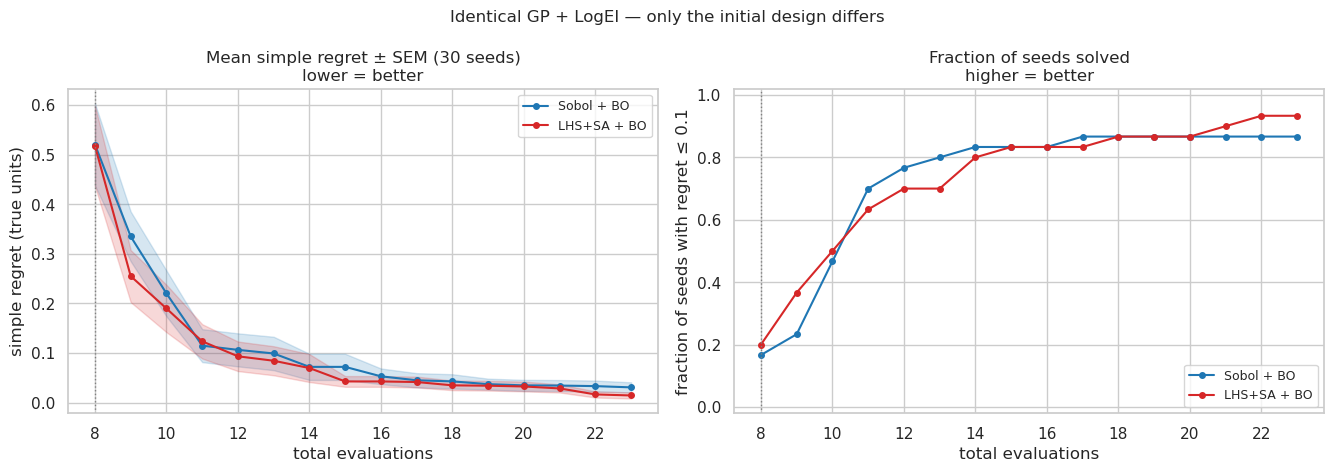

In [5]:
TOL = 0.1   # "solved" tolerance on simple regret

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
for key, (label, color) in ARMS.items():
    r = R[key]
    mu, sem = r.mean(0), r.std(0) / np.sqrt(r.shape[0])
    axes[0].plot(evals, mu, '-o', color=color, label=label, markersize=4)
    axes[0].fill_between(evals, mu - sem, mu + sem, color=color, alpha=0.18)
    axes[1].plot(evals, (r <= TOL).mean(0), '-o', color=color, label=label, markersize=4)
axes[0].set_xlabel('total evaluations'); axes[0].set_ylabel('simple regret (true units)')
axes[0].set_title(f'Mean simple regret ± SEM ({R["sobol"].shape[0]} seeds)\nlower = better')
axes[1].set_xlabel('total evaluations'); axes[1].set_ylabel(f'fraction of seeds with regret ≤ {TOL}')
axes[1].set_title('Fraction of seeds solved\nhigher = better'); axes[1].set_ylim(-0.02, 1.02)
for ax in axes: ax.legend(fontsize=9); ax.axvline(N_INIT, ls=':', color='gray', lw=1)
fig.suptitle('Identical GP + LogEI — only the initial design differs', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'regret_comparison.png'), dpi=180, bbox_inches='tight')
plt.show()

In [6]:
rows = []
for key, (label, _) in ARMS.items():
    r, runs = R[key], results[key]
    solved = (r <= TOL)
    first = np.array([evals[s.argmax()] if s.any() else np.nan for s in solved])
    rows.append({
        'arm': label,
        'init discrepancy (mean)':   round(float(np.mean([x['init_disc'] for x in runs])), 4),
        'init min dist (mean)':      round(float(np.mean([x['init_mind'] for x in runs])), 4),
        'regret after init (mean)':  round(float(r[:, 0].mean()), 3),
        'final regret (mean)':       round(float(r[:, -1].mean()), 4),
        'final regret (median)':     round(float(np.median(r[:, -1])), 4),
        f'seeds solved (regret<={TOL})': f'{int(solved[:, -1].sum())}/{r.shape[0]}',
        'median evals to solve':     float(np.nanmedian(first)),
    })
summary = pd.DataFrame(rows)
summary.to_excel(os.path.join(OUT_DIR, 'benchmark_summary.xlsx'), index=False)

final_s, final_l = R['sobol'][:, -1], R['lhs_sa'][:, -1]
wins_l = int((final_l < final_s - 1e-9).sum()); wins_s = int((final_s < final_l - 1e-9).sum())
print(f'Per-seed final-regret wins: LHS+SA {wins_l} | Sobol {wins_s} | '
      f'ties {R["sobol"].shape[0] - wins_l - wins_s}')
summary

Per-seed final-regret wins: LHS+SA 14 | Sobol 11 | ties 5


,arm,init discrepancy (mean),init min dist (mean),regret after init (mean),final regret (mean),final regret (median),seeds solved (regret<=0.1),median evals to solve
0,Sobol + BO,0.0958,0.1052,0.520,0.0308,0.0058,26/30,10.0
1,LHS+SA + BO,0.0953,0.1530,0.518,0.0145,0.0056,28/30,10.0


## 5. Conclusion

The two arms share every component downstream of initialization, so any separation is
attributable to the initial design alone. Over 30 seeds:

* **Equal footing after the initial batch** — mean regret after the 8 initial points is
  identical (0.518 vs 0.520); at n = 8 in 2-D both samplers produce good designs
  (discrepancy ≈ 0.095 for both; LHS+SA has ~1.5× the minimum spacing).
* **BO converges at least as fast from LHS+SA** — mean final regret 0.0145 vs 0.0308,
  28/30 vs 26/30 seeds solved, per-seed wins 14 : 11 (5 ties), identical median
  evals-to-solve (10). The curves overlap within ±1 SEM for most of the run — the edge is
  small and not statistically decisive.

**Answer to the question:** there is **no reason to prefer Sobol** — the initializer does not
handicap BO in either direction at this scale, so the choice correctly rests on the
design-quality criteria (space-filling, factor independence, extensibility), where LHS+SA won
clearly. Note this 2-D toy actually *flatters* Sobol: its real weakness in the campaign setting —
factor correlations up to ~0.45 in 9-D under the as-fabricated grid — cannot appear with only two
inputs, and even so it gains nothing here.

**Caveats.** Smooth objective, modest noise, single objective, 2-D; a 9-factor replicate-noise
version would be a heavier but more faithful test. The result supports the choice already made
for the campaign: **LHS + SA**.